# This is challenge 9 part A

Linear (lstsq): MSE = 0.3468   R-squared = 0.3474
Polyfit degree 1:  MSE = 0.3468   R-squared = 0.3474
Polyfit degree 2:  MSE = 0.3447   R-squared = 0.3514
Polyfit degree 3:  MSE = 0.3421   R-squared = 0.3563

Polynomial degree 3 is the better fit


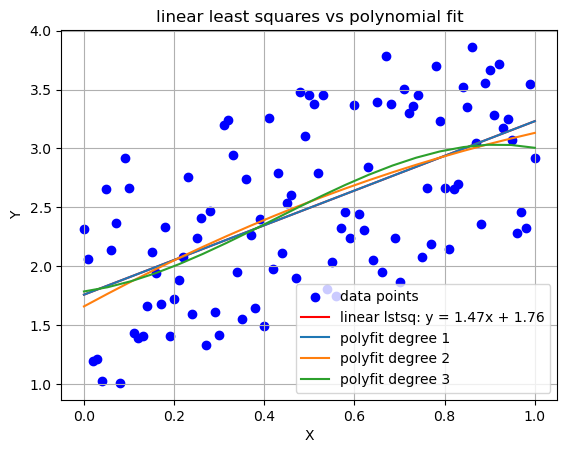

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

# generate data
np.random.seed(42)
m_true = np.random.uniform(0.5, 3.0)
b_true = np.random.uniform(-1.0, 2.0)

X = np.arange(0, 1.01, 0.01)
noise = np.random.uniform(-1, 1, len(X))

# 
Y = m_true * X + b_true + noise

# least squares linear fit
A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
Y_pred_linear = m * X + c

# mse and r-squared for linear
mse_linear = np.mean((Y - Y_pred_linear)**2)
ss_total = np.sum((Y - np.mean(Y))**2)
r_squared_linear = 1 - (np.sum((Y - Y_pred_linear)**2) / ss_total)

print(f"Linear (lstsq): MSE = {mse_linear:.4f}   R-squared = {r_squared_linear:.4f}")

# try degree 1, 2, and 3 with polyfit
X_line = np.linspace(X.min(), X.max(), 20)

plt.figure()
plt.scatter(X, Y, color="blue", label="data points")
plt.plot(X_line, m * X_line + c, color="red", label=f"linear lstsq: y = {m:.2f}x + {c:.2f}")

best_degree = 1
best_mse = mse_linear

for degree in [1, 2, 3]:
    coefficients = np.polyfit(X, Y, degree)
    polynomial = np.poly1d(coefficients)
    Y_pred_poly = polynomial(X)

    mse = np.mean((Y - Y_pred_poly)**2)
    r_squared = 1 - (np.sum((Y - Y_pred_poly)**2) / ss_total)

    print(f"Polyfit degree {degree}:  MSE = {mse:.4f}   R-squared = {r_squared:.4f}")

    # 
    plt.plot(X_line, polynomial(X_line), label=f"polyfit degree {degree}")

    if mse < best_mse:
        best_mse = mse
        best_degree = degree

print()
if best_degree == 1 and best_mse == mse_linear:
    print("Linear least squares is the better fit")
else:
    print(f"Polynomial degree {best_degree} is the better fit")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("linear least squares vs polynomial fit")
plt.legend()
plt.grid(True)
plt.show()

# This is part b where we will do a similar process, but continue increasing our degrees by one until we are "overfitting"

## In class, it was said that anything near a polynomial fit of degree 10 is too high so for this challenge we will go to a power of 15 to see overfittings effects

Linear (lstsq): MSE = 0.3468   R-squared = 0.3474

Polyfit degree  1:  MSE = 0.3468   R-squared = 0.3474
Polyfit degree  2:  MSE = 0.3447   R-squared = 0.3514
Polyfit degree  3:  MSE = 0.3421   R-squared = 0.3563



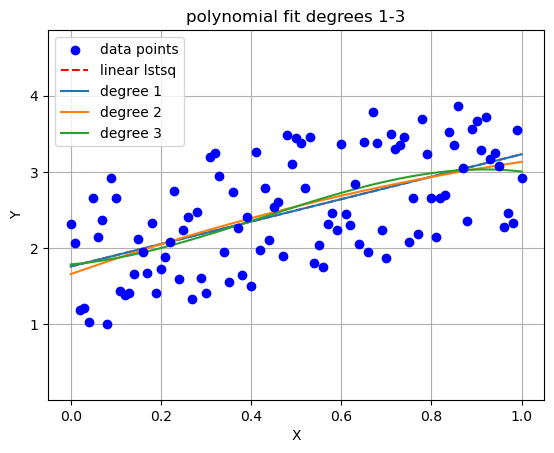

Polyfit degree  4:  MSE = 0.3421   R-squared = 0.3563
Polyfit degree  5:  MSE = 0.3376   R-squared = 0.3647
Polyfit degree  6:  MSE = 0.3356   R-squared = 0.3685



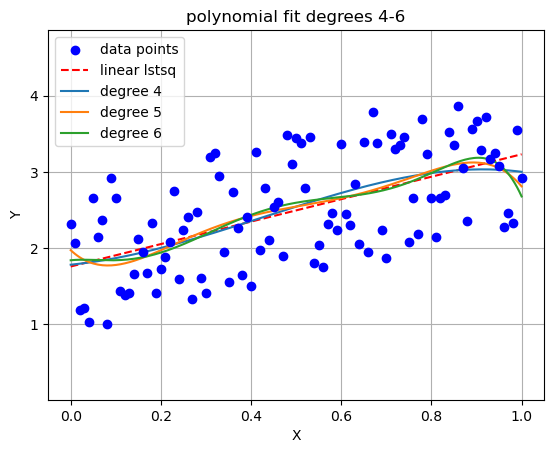

Polyfit degree  7:  MSE = 0.3354   R-squared = 0.3688
Polyfit degree  8:  MSE = 0.3343   R-squared = 0.3710
Polyfit degree  9:  MSE = 0.3342   R-squared = 0.3710



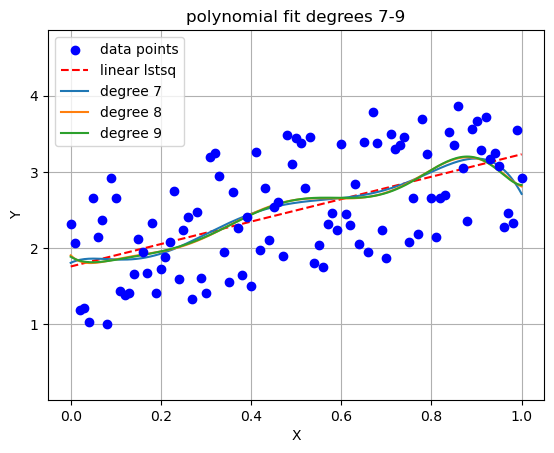

Polyfit degree 10:  MSE = 0.3278   R-squared = 0.3831
Polyfit degree 11:  MSE = 0.3275   R-squared = 0.3837
Polyfit degree 12:  MSE = 0.3067   R-squared = 0.4229



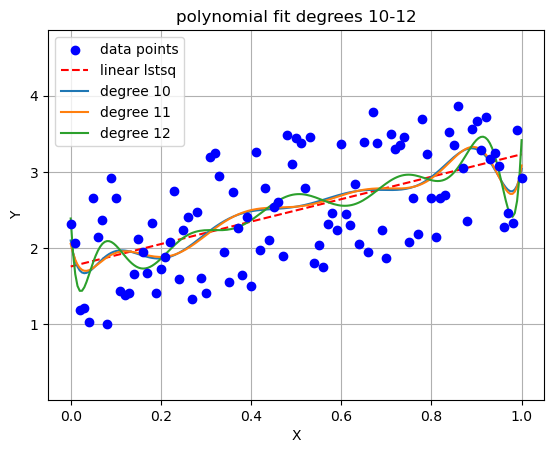

Polyfit degree 13:  MSE = 0.3017   R-squared = 0.4323
Polyfit degree 14:  MSE = 0.2984   R-squared = 0.4385
Polyfit degree 15:  MSE = 0.2976   R-squared = 0.4400



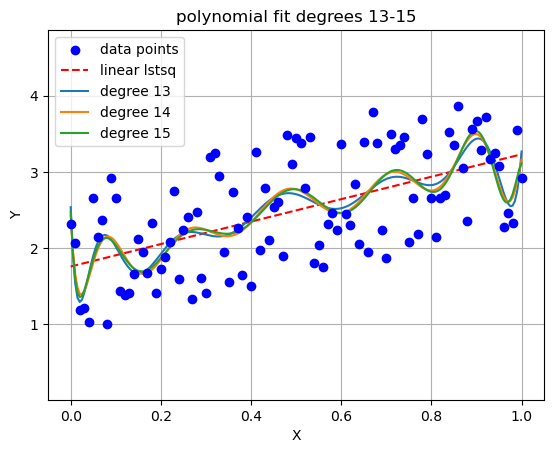

In [4]:

import numpy as np
import matplotlib.pyplot as plt
import random
import math

# generate data
np.random.seed(42)
m_true = np.random.uniform(0.5, 3.0)
b_true = np.random.uniform(-1.0, 2.0)

X = np.arange(0, 1.01, 0.01)
noise = np.random.uniform(-1, 1, len(X))

# 
Y = m_true * X + b_true + noise

# least squares linear fit
A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
Y_pred_linear = m * X + c

# mse and r-squared for linear
ss_total = np.sum((Y - np.mean(Y))**2)
mse_linear = np.mean((Y - Y_pred_linear)**2)
r_squared_linear = 1 - (np.sum((Y - Y_pred_linear)**2) / ss_total)

print(f"Linear (lstsq): MSE = {mse_linear:.4f}   R-squared = {r_squared_linear:.4f}")
print()



# group degrees into sets of 3

# at first I had all 15 polynomial curves on one graph and it was really messy so I decided to separate it into 5 different graphs to better see the underfit
# vs overfit curves


degree_groups = [[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12], [13, 14, 15]]

X_line = np.linspace(X.min(), X.max(), 200)

for group in degree_groups:
    plt.figure()
    plt.scatter(X, Y, color='blue', label='data points', zorder=5)
    plt.plot(X_line, m * X_line + c, color='red', linestyle='--', label=f'linear lstsq')

    for degree in group:
        coefficients = np.polyfit(X, Y, degree)
        polynomial = np.poly1d(coefficients)
        Y_pred_poly = polynomial(X)

        mse = np.mean((Y - Y_pred_poly)**2)
        r_squared = 1 - (np.sum((Y - Y_pred_poly)**2) / ss_total)

        print(f"Polyfit degree {degree:2d}:  MSE = {mse:.4f}   R-squared = {r_squared:.4f}")

        # 
        plt.plot(X_line, polynomial(X_line), label=f'degree {degree}')

    print()
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title(f'polynomial fit degrees {group[0]}-{group[-1]}')
    plt.legend()
    plt.grid(True)
    plt.ylim(Y.min() - 1, Y.max() + 1)
    plt.show()



# This is part C of the challenges and we will now code a polynomial fit using this new matrix and its elements (the powers of its points i j locations)


Vandermonde degree  1:  MSE = 0.3468   R-squared = 0.3474
Vandermonde degree  2:  MSE = 0.3447   R-squared = 0.3514
Vandermonde degree  3:  MSE = 0.3421   R-squared = 0.3563
Vandermonde degree  4:  MSE = 0.3421   R-squared = 0.3563
Vandermonde degree  5:  MSE = 0.3376   R-squared = 0.3647
Vandermonde degree  6:  MSE = 0.3356   R-squared = 0.3685
Vandermonde degree  7:  MSE = 0.3354   R-squared = 0.3688
Vandermonde degree  8:  MSE = 0.3343   R-squared = 0.3710
Vandermonde degree  9:  MSE = 0.3342   R-squared = 0.3710
Vandermonde degree 10:  MSE = 0.3278   R-squared = 0.3831
Vandermonde degree 11:  MSE = 0.3275   R-squared = 0.3837
Vandermonde degree 12:  MSE = 0.3191   R-squared = 0.3995
Vandermonde degree 13:  MSE = 0.3111   R-squared = 0.4146
Vandermonde degree 14:  MSE = 0.3075   R-squared = 0.4213
Vandermonde degree 15:  MSE = 0.3079   R-squared = 0.4206


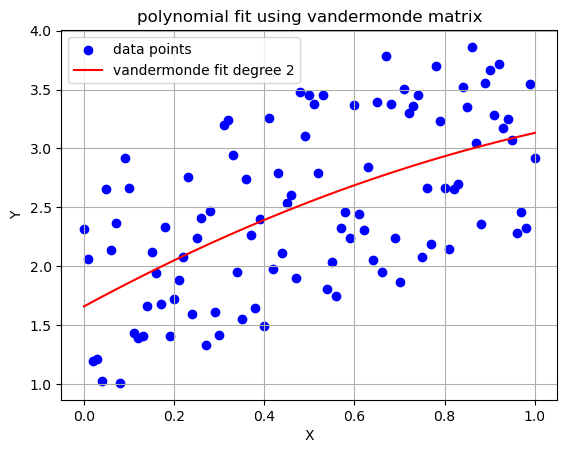

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

# generate data - same as challenge a
np.random.seed(42)
m_true = np.random.uniform(0.5, 3.0)
b_true = np.random.uniform(-1.0, 2.0)

X = np.arange(0, 1.01, 0.01)
noise = np.random.uniform(-1, 1, len(X))

# 
Y = m_true * X + b_true + noise

# create vandermonde matrix for a given degree
def create_vandermonde_matrix(x, degree):
    V = np.zeros((len(x), degree + 1))
    for i in range(degree + 1):
        V[:, i] = x**i
    return V

ss_total = np.sum((Y - np.mean(Y))**2)
X_line = np.linspace(X.min(), X.max(), 200)

# loop through degrees 1 to 15
for degree in range(1, 16):
    V = create_vandermonde_matrix(X, degree)

    # V.T * V
    VT_V = np.dot(V.T, V)
    # V.T * y
    VT_y = np.dot(V.T, Y)
    # solve for coefficients
    coefficients = np.linalg.solve(VT_V, VT_y)

    # predicted values
    Y_pred = np.dot(V, coefficients)

    # mse and r-squared
    mse = np.mean((Y - Y_pred)**2)
    r_squared = 1 - (np.sum((Y - Y_pred)**2) / ss_total)

    # 
    print(f"Vandermonde degree {degree:2d}:  MSE = {mse:.4f}   R-squared = {r_squared:.4f}")

# plot just degree 2 as example
degree = 2
V = create_vandermonde_matrix(X, degree)
VT_V = np.dot(V.T, V)
VT_y = np.dot(V.T, Y)
coefficients = np.linalg.solve(VT_V, VT_y)
V_line = create_vandermonde_matrix(X_line, degree)
Y_line = np.dot(V_line, coefficients)

plt.figure()
plt.scatter(X, Y, color="blue", label="data points")
plt.plot(X_line, Y_line, color="red", label=f"vandermonde fit degree {degree}")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("polynomial fit using vandermonde matrix")
plt.legend()
plt.grid(True)
plt.show()

# I dont remember if he wanted error for each degree of polynomial, or not so to be safe ill print it out for every iteration.
#also I am going to rename it chapter 10 fix this and then resubmit it, I thought it was challenge 9, but in canvas it goes from 8-10 so this is challenge 10

#we see that the MSE error is greater than other polynomial fits  and R squared error is lower deeming it another suitable method for finding creating curves for data points
